In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.shape

(1470, 35)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [12]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
df.duplicated().sum()

np.int64(0)

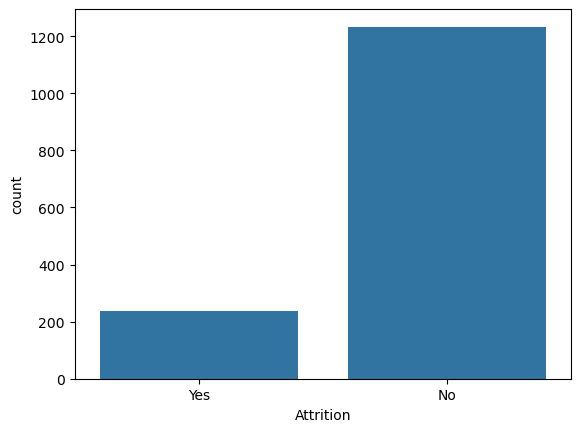

In [14]:
sns.countplot(
    x='Attrition',
    data=df
)

plt.show()

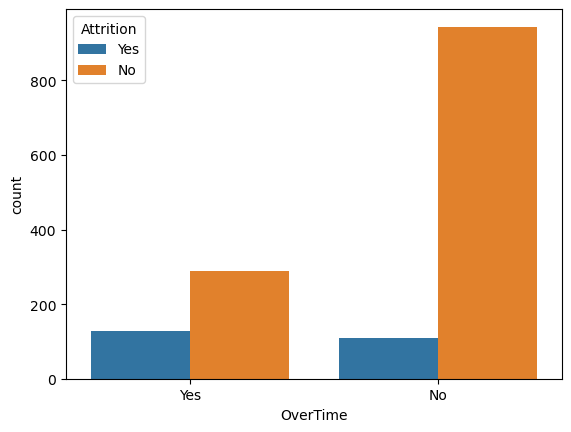

In [15]:
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df
)

plt.show()

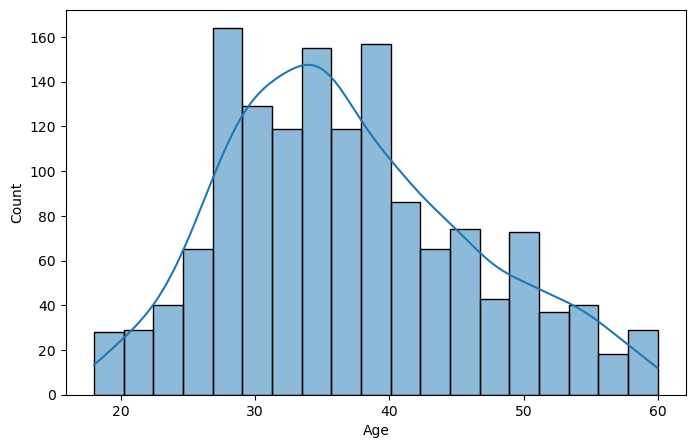

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    kde=True
)

plt.show()

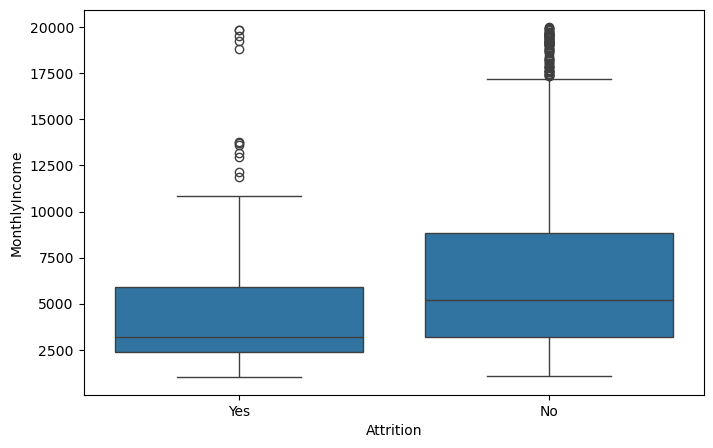

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.show()

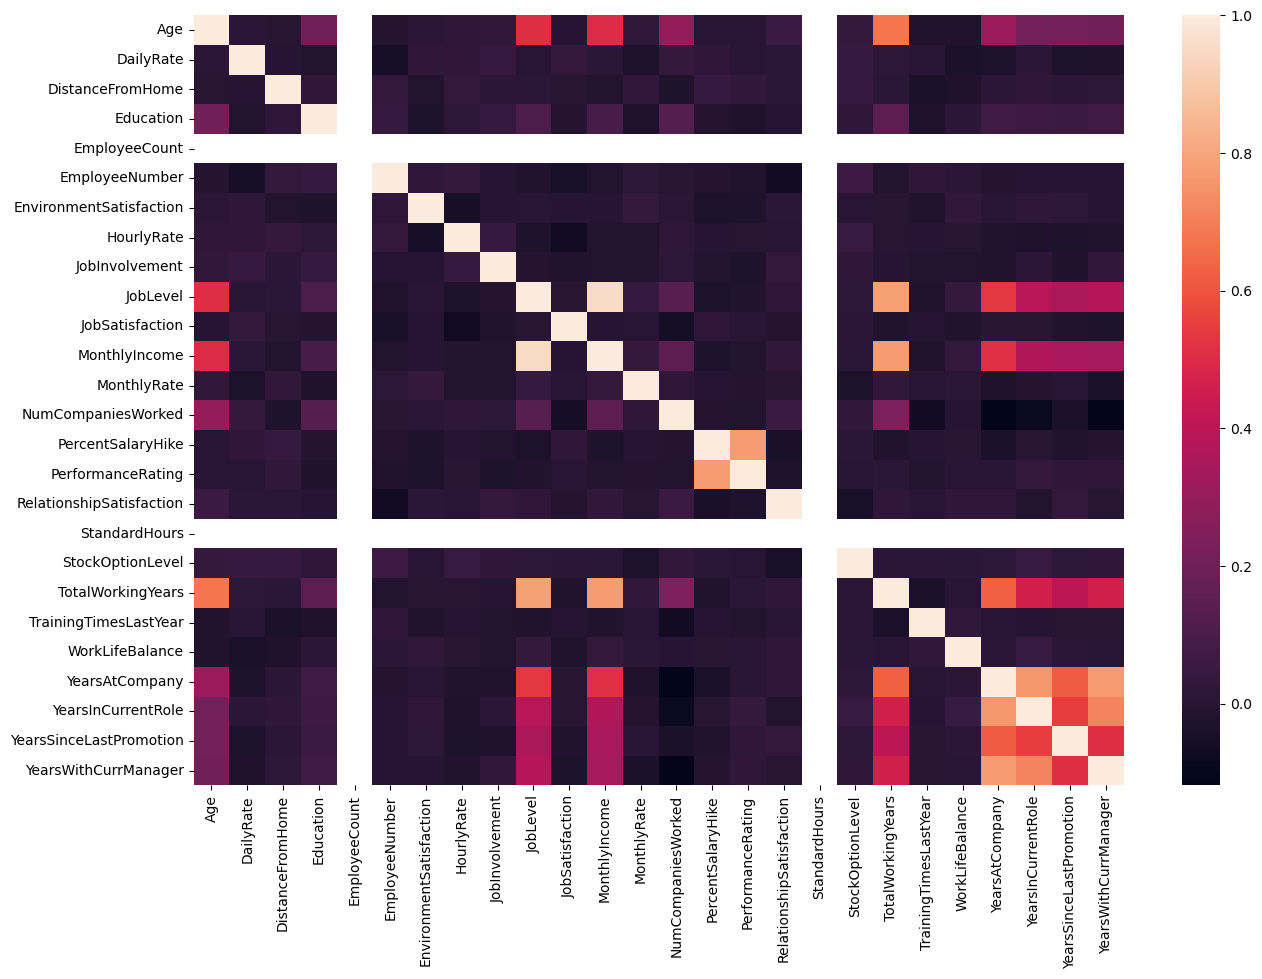

In [18]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.select_dtypes(
        include=np.number
    ).corr(),
    annot=False
)

plt.show()

In [21]:
features = [
    'Age',
    'MonthlyIncome',
    'YearsAtCompany',
    'JobSatisfaction',
    'WorkLifeBalance',
    'DistanceFromHome',
    'OverTime',
    'Attrition'
]

df=df[features]


In [22]:
df

,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,DistanceFromHome,OverTime,Attrition
0,41,5993,6,4,1,1,Yes,Yes
1,49,5130,10,2,3,8,No,No
2,37,2090,0,3,3,2,Yes,Yes
3,33,2909,8,3,3,3,Yes,No
4,27,3468,2,2,3,2,No,No
...,...,...,...,...,...,...,...,...
1465,36,2571,5,4,3,23,No,No
1466,39,9991,7,1,3,6,No,No
1467,27,6142,6,2,3,4,Yes,No
1468,49,5390,9,2,2,2,No,No


In [23]:
df['OverTime'] = df['OverTime'].map({'Yes':1,'No':0})

In [24]:
df["OverTime"].head(5)

0    1
1    0
2    1
3    1
4    0
Name: OverTime, dtype: int64

In [25]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

In [26]:
df["Attrition"].head(5)

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [27]:
X = df.drop('Attrition',axis=1)

y = df['Attrition']

In [28]:
X

,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,DistanceFromHome,OverTime
0,41,5993,6,4,1,1,1
1,49,5130,10,2,3,8,0
2,37,2090,0,3,3,2,1
3,33,2909,8,3,3,3,1
4,27,3468,2,2,3,2,0
...,...,...,...,...,...,...,...
1465,36,2571,5,4,3,23,0
1466,39,9991,7,1,3,6,0
1467,27,6142,6,2,3,4,1
1468,49,5390,9,2,2,2,0


In [29]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [ ]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)

rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [35]:

y_pred = rf.predict(X_test)


In [36]:
accuracy_score(y_test,y_pred)

0.8503401360544217

In [37]:
print( classification_report( y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       255
           1       0.35      0.15      0.21        39

    accuracy                           0.85       294
   macro avg       0.62      0.56      0.57       294
weighted avg       0.81      0.85      0.82       294



In [38]:
confusion_matrix( y_test,y_pred)

array([[244,  11],
       [ 33,   6]])

In [40]:
import joblib

joblib.dump(rf,'model/attrition_model.pkl')

joblib.dump(scaler,'model/scaler.pkl')

['model/scaler.pkl']